In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

url = "/content/drive/MyDrive/Decryptogen/personality_dataset.csv"

df = pd.read_csv(url)

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [5]:
NUMERIC_COLS = ['Time_spent_Alone', 'Social_event_attendance','Going_outside', 'Friends_circle_size', 'Post_frequency']

CAT_COLS = ['Stage_fear', 'Drained_after_socializing']

ALL_FEATURES = NUMERIC_COLS + CAT_COLS

TARGET       = 'Personality'

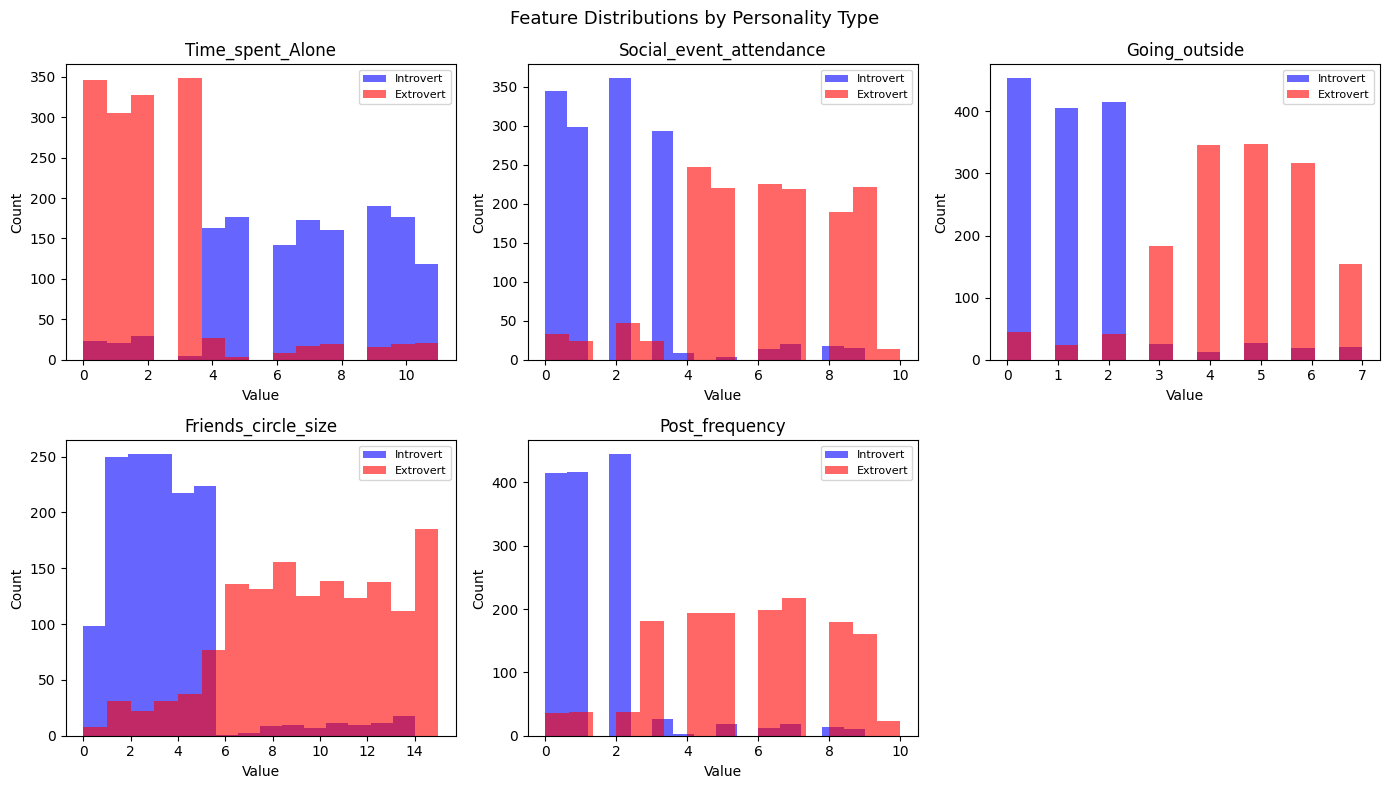

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    for label, color in [('Introvert', 'b'), ('Extrovert', 'r')]:
        data = df[df['Personality'] == label][col].dropna()
        axes[i].hist(data, bins=15, alpha=0.6, label=label, color=color)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)

fig.suptitle('Feature Distributions by Personality Type', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
df.isnull().sum()

,0
Time_spent_Alone,63
Stage_fear,73
Social_event_attendance,62
Going_outside,66
Drained_after_socializing,52
Friends_circle_size,77
Post_frequency,65
Personality,0


In [8]:
df.shape

(2900, 8)

In [9]:

df[NUMERIC_COLS].describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

X = df[ALL_FEATURES].copy()
y = (df[TARGET] == 'Introvert').astype(int)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['No', 'Yes']] * 2,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUMERIC_COLS),
    ('cat', cat_pipe, CAT_COLS)
])

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name,clf in MODELS.items():
    pipe   = Pipeline([('pre', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    results.append({'Model': name, 'CV Accuracy': scores.mean(), 'Std': scores.std()})
    print(f'{name:25s}  acc={scores.mean():.4f} ± {scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV Accuracy', ascending=False)

Logistic Regression        acc=0.9332 ± 0.0084
Random Forest              acc=0.9280 ± 0.0044
Gradient Boosting          acc=0.9379 ± 0.0091


In [23]:
print(f'\nBest model:{results_df.iloc[0]["Model"]}')


Best model:Gradient Boosting


In [24]:
final_clf = MODELS[results_df.iloc[0]['Model']]
final_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', final_clf)
])

final_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['No',
                                                                                               'Yes'],
                                                                                              ['No',
                                                                                               'Yes']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('clf',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred  = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
auc     = roc_auc_score(y_test, y_proba)

print(f'Test Accuracy: {acc:.4f}')
print(f'ROC-AUC: {auc:.4f}')
print(classification_report(y_test, y_pred, target_names=['Extrovert', 'Introvert']))

Test Accuracy: 0.9172
ROC-AUC: 0.9559
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



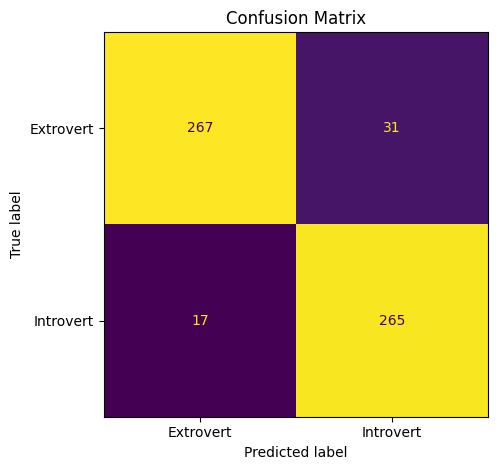

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Extrovert', 'Introvert'],
    colorbar=False
)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [28]:
import os, joblib

path = '/content/drive/MyDrive/Decryptogen/model'

os.makedirs(path, exist_ok=True)
joblib.dump(final_pipe, f'{path}/model.pkl')

['/content/drive/MyDrive/Decryptogen/model/model.pkl']